In [117]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.data_utils import load_data, img_path, filter_samples, load_merged_samples, load_samples_out
file_type = ".pdf"

In [119]:
plt.rcParams['figure.figsize'] = [6, 5]
plt.rcParams['figure.dpi'] = 100
plt.rcParams.update({'font.size': 14})

In [120]:
data = load_data()
datasets = list(data.keys())

In [121]:
cutoff = np.arange(0, 1, 0.0005)
sample_count = {}
for k, v in data.items():
    sample_count[k] = []
    for i in cutoff:
        below = v.samples.query(f"ane_total_cn_frac_aut <= {i}").shape[0]
        sample_count[k].append(below / v.samples.shape[0])

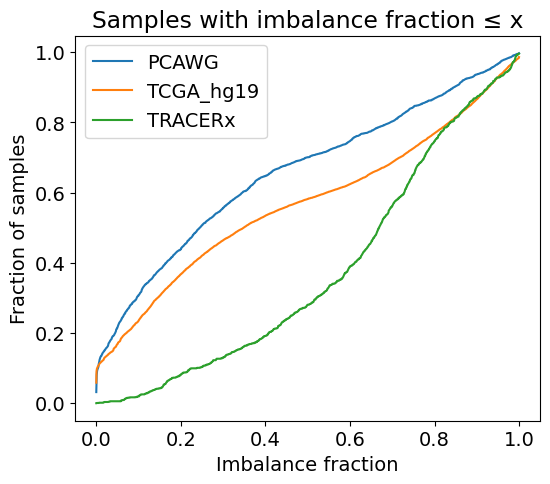

In [122]:
for k, v in sample_count.items():
    plt.plot(cutoff, v, label=k)
plt.xlabel("Imbalance fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with imbalance fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_imbalance_fraction_full{file_type}", bbox_inches="tight")

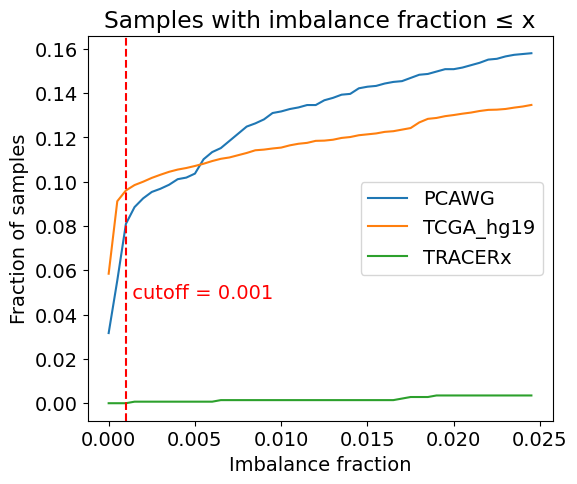

In [123]:
for k, v in sample_count.items():
    plt.plot(cutoff[:50], v[:50], label=k)
# add a vertical line at 0.01
plt.axvline(x=0.001, color="red", linestyle="--")
plt.xlabel("Imbalance fraction")
plt.ylabel("Fraction of samples")
plt.title(f"Samples with imbalance fraction ≤ x")
plt.legend()
# add a text to the vertical line
plt.text(0.001, 0.05, " cutoff = 0.001", rotation=0, verticalalignment="center", horizontalalignment="left", color="red")


plt.savefig(f"{img_path}/fig_samples_imbalance_fraction{file_type}", bbox_inches="tight")

In [124]:
cutoff = np.arange(0, 1.001, 0.001)
coverage_count = {}
for k, v in data.items():
    coverage_count[k] = []
    for i in cutoff:
        below = v.samples.query(f"cover_frac_aut <= {i}").shape[0]
        coverage_count[k].append(below / v.samples.shape[0])

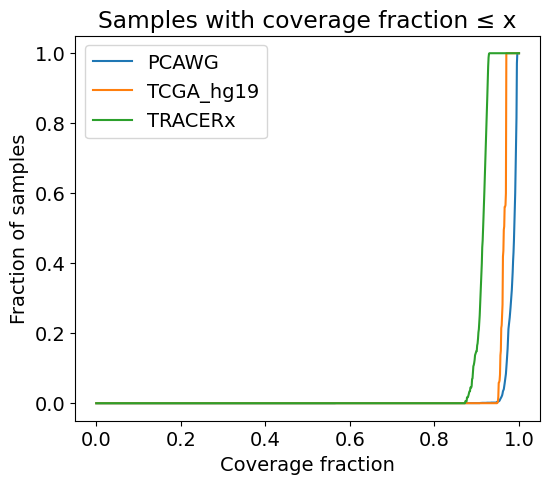

In [125]:
for k, v in coverage_count.items():
    plt.plot(cutoff, v, label=k)

plt.xlabel("Coverage fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title("Samples with coverage fraction ≤ x")


plt.savefig(f"{img_path}/fig_samples_coverage_fraction_full{file_type}", bbox_inches="tight")

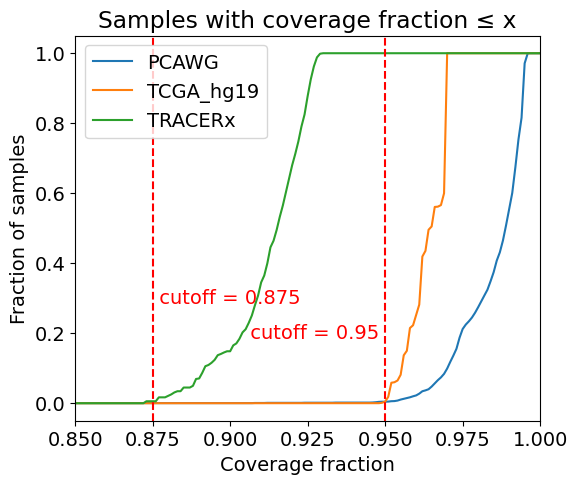

In [126]:
for k, v in coverage_count.items():
    plt.plot(cutoff, v, label=k)
plt.xlim(0.85, 1)

# add vertical line at .95
plt.axvline(x=0.95, color="red", linestyle="--")
plt.xlabel("Coverage fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title("Samples with coverage fraction ≤ x")

# add a text to the vertical line
plt.text(0.95, 0.2, " cutoff = 0.95 ", rotation=0, verticalalignment="center", horizontalalignment="right", color="red")

plt.axvline(x=0.875, color="red", linestyle="--")
plt.text(0.875, 0.3, " cutoff = 0.875 ", rotation=0, verticalalignment="center", horizontalalignment="left", color="red")

plt.savefig(f"{img_path}/fig_samples_coverage_fraction{file_type}", bbox_inches="tight")

In [130]:
cutoff = np.arange(0, 1001, 1)
break_count = {}
for k, v in data.items():
    break_count[k] = []
    for i in cutoff:
        below = v.samples.query(f"breaks_aut <= {i}").shape[0]
        break_count[k].append(below / v.samples.shape[0])

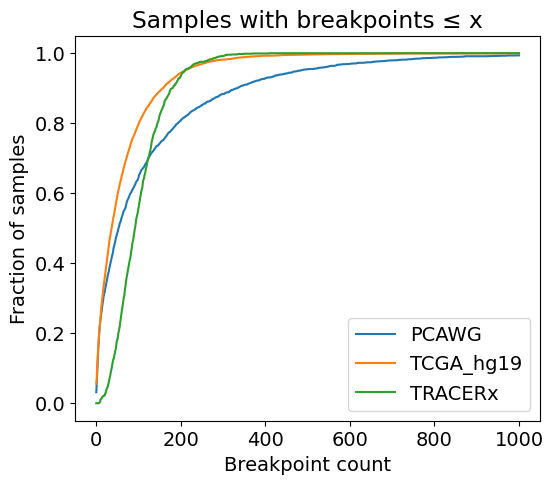

In [131]:
for k, v in break_count.items():
    plt.plot(cutoff, v, label=k)
plt.xlabel("Breakpoint count")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with breakpoints ≤ x")

plt.savefig(f"{img_path}/fig_samples_breaks_fraction_full{file_type}", bbox_inches="tight")

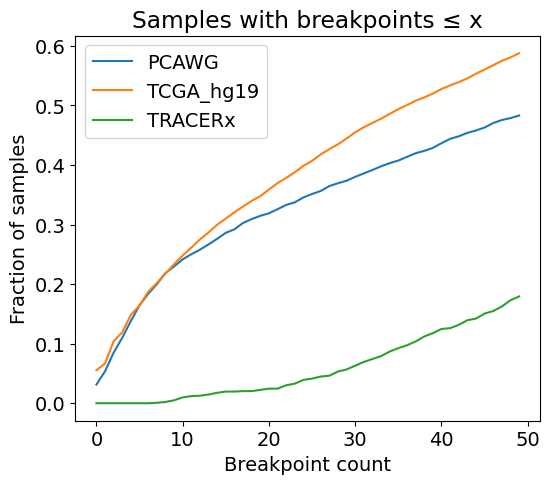

In [132]:
for k, v in break_count.items():
    plt.plot(cutoff[:50], v[:50], label=k)

plt.xlabel("Breakpoint count")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with breakpoints ≤ x")

plt.savefig(f"{img_path}/fig_samples_breaks_fraction{file_type}", bbox_inches="tight")